In [85]:
def date_prepocessing(df):
    df["DATETIME"] = pd.to_datetime(df["DATE"].astype(str) + " " + df["TIME"].astype(str), format="mixed")
    df = df.set_index("DATETIME")
    del df["DATE"]
    del df["TIME"]
    del df["TOTAL GENERATION (PV1+PV2)"]
    del df["GENERATION (PV1)"]
    del df["GENERATION (PV2)"]
    del df["INYECTION TO NETWORK (KWh negtive inyect)"]
    
    # Crear un rango horario completo entre la fecha mínima y máxima
    fecha_min = df.index.min()
    fecha_max = df.index.max()
    rango_horario_completo = pd.date_range(start=fecha_min, end=fecha_max, freq="15min")
    
    # Reindexar el dataframe con el rango completo y rellenar con NaN
    df = df.reindex(rango_horario_completo)
    
    # Interpolar linealmente los datos faltantes (horas del cambio de hora)
    df = df.interpolate(method="linear")
    
    # Renombrar el índice
    df.index.name = "DATETIME"  
    
    return df

df = date_prepocessing(df)

Forma nueva para insertar anomalias

In [ ]:
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURACIÓN
# =============================================================================

# Columna donde se modificarán los valores
TARGET_COLUMN = "PLANT CONSUMPTION (KWh)"

# División de los datos:
# 80 % entrenamiento, 10 % validación y 10 % test
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10

# Porcentaje de anomalías que se insertará en el conjunto de test
ANOMALY_PERCENTAGE = 0.0034

# Un spike será 2.5 veces el máximo habitual
SPIKE_FACTOR = 2.5

# Un drop será el 10 % del mínimo habitual
DROP_FACTOR = 0.10

# Semilla para obtener siempre las mismas anomalías
RANDOM_SEED = 42

# Separación mínima entre anomalías
# 4 lecturas de 15 minutos equivalen a una hora
MIN_DISTANCE_READINGS = 100

# Como máximo, el 85 % de los días podrá contener anomalías
ANOMALY_DAY_FRACTION = 0.85

# Número de primeras lecturas del test que se reservan
# para formar la ventana temporal inicial del modelo
RESERVED_READINGS = 96


# =============================================================================
# COMPROBACIONES INICIALES
# =============================================================================

if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError(
        "El índice de df debe ser de tipo DatetimeIndex."
    )

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"No existe la columna '{TARGET_COLUMN}'. "
        f"Columnas disponibles: {df.columns.tolist()}"
    )

# Evitar ejecutar dos veces la inserción de anomalías
if (
    "is_anomaly" in df.columns
    and df["is_anomaly"].eq(1).any()
):
    raise RuntimeError(
        "df ya contiene anomalías. "
        "Vuelve a cargar los datos originales antes de ejecutar esta celda."
    )


# =============================================================================
# ELIMINAR FECHAS DUPLICADAS
# =============================================================================

if df.index.has_duplicates:

    # Contar cuántas filas repetidas existen
    numero_duplicados = df.index.duplicated(
        keep="first"
    ).sum()

    print(
        f"Se encontraron {numero_duplicados} fechas duplicadas."
    )

    # Asegurar que el índice tiene un nombre
    if df.index.name is None:
        df.index.name = "datetime"

    nombre_indice = df.index.name

    # Pasar temporalmente la fecha a una columna
    df.reset_index(inplace=True)

    # Conservar solamente la primera fila de cada fecha
    df.drop_duplicates(
        subset=[nombre_indice],
        keep="first",
        inplace=True
    )

    # Volver a colocar la fecha como índice
    df.set_index(
        nombre_indice,
        inplace=True
    )

    print(
        "Se conservó la primera lectura de cada fecha."
    )


# Ordenar cronológicamente
df.sort_index(inplace=True)

df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)


df["is_anomaly"] = 0
df["anomaly_type"] = "none"


# =============================================================================
# =============================================================================

numero_total_datos = len(df)

numero_train = int(
    TRAIN_SIZE * numero_total_datos
)

numero_validacion = int(
    VAL_SIZE * numero_total_datos
)

inicio_test = numero_train + numero_validacion

test = df.iloc[inicio_test:]

if test.empty:
    raise ValueError(
        "El conjunto de test está vacío."
    )

if len(test) <= RESERVED_READINGS:
    raise ValueError(
        "El conjunto de test no contiene suficientes registros "
        "después de reservar las primeras 96 lecturas."
    )

valid_test = test[
    [TARGET_COLUMN]
].dropna().copy()

if valid_test.empty:
    raise ValueError(
        "El conjunto de test no contiene valores válidos."
    )


# =============================================================================
# CREAR INFORMACIÓN TEMPORAL
# =============================================================================

# lunes = 0, martes = 1, ..., domingo = 6
valid_test["_weekday"] = (
    valid_test.index.dayofweek
)

# Por ejemplo: 00:00, 00:15, 00:30...
valid_test["_reading_time"] = (
    valid_test.index.time
)


# =============================================================================
# =============================================================================

# - día de la semana
# - momento exacto de la lectura
groups = valid_test.groupby(
    ["_weekday", "_reading_time"],
    sort=False
)

group_values = groups[TARGET_COLUMN].agg(
    max_value="max",
    min_value="min"
)

group_values["max_timestamp"] = (
    groups[TARGET_COLUMN].idxmax()
)

group_values["min_timestamp"] = (
    groups[TARGET_COLUMN].idxmin()
)

group_values["group_size"] = (
    groups[TARGET_COLUMN].size()
)

group_values = group_values[
    group_values["group_size"] >= 2
]

if group_values.empty:
    raise ValueError(
        "No existen suficientes lecturas repetidas "
        "por día de la semana y momento de lectura."
    )

valid_test = valid_test.join(
    group_values,
    on=["_weekday", "_reading_time"],
    how="inner"
)


# =============================================================================
# CALCULAR EL NÚMERO DE ANOMALÍAS
# =============================================================================

numero_anomalias = int(
    round(
        len(test) * ANOMALY_PERCENTAGE
    )
)

if numero_anomalias % 2 != 0:
    numero_anomalias -= 1

if numero_anomalias < 2:
    raise ValueError(
        "El conjunto de test es demasiado pequeño "
        "para insertar anomalías."
    )

numero_spikes = numero_anomalias // 2
numero_drops = numero_anomalias // 2


# =============================================================================
# SELECCIONAR LOS DÍAS CON ANOMALÍAS
# =============================================================================

dias_disponibles = pd.DatetimeIndex(
    valid_test.index.normalize().unique()
)

numero_dias_seleccionados = int(
    np.ceil(
        len(dias_disponibles)
        * ANOMALY_DAY_FRACTION
    )
)

numero_dias_seleccionados = min(
    numero_dias_seleccionados,
    len(dias_disponibles) - 1
)

numero_dias_seleccionados = max(
    numero_dias_seleccionados,
    1
)


# =============================================================================
# FECHAS RESERVADAS PARA LA VENTANA TEMPORAL
# =============================================================================


fechas_reservadas = set(
    test.index[:RESERVED_READINGS]
)


# =============================================================================
# SELECCIONAR LAS FECHAS DE LAS ANOMALÍAS
# =============================================================================


posiciones_test = {
    fecha: posicion
    for posicion, fecha in enumerate(test.index)
}

spikes_seleccionados = []
drops_seleccionados = []

seleccion_completada = False



for intento in range(200):

    rng = np.random.default_rng(
        RANDOM_SEED + intento
    )


    dias_seleccionados = pd.DatetimeIndex(
        rng.choice(
            np.asarray(
                dias_disponibles,
                dtype="datetime64[ns]"
            ),
            size=numero_dias_seleccionados,
            replace=False
        )
    )


    candidatos = valid_test[
        valid_test.index.normalize().isin(
            dias_seleccionados
        )
    ]


    candidatos_spike = candidatos[
        candidatos.index
        != candidatos["max_timestamp"]
    ].index.to_list()

    candidatos_drop = candidatos[
        candidatos.index
        != candidatos["min_timestamp"]
    ].index.to_list()


    rng.shuffle(candidatos_spike)
    rng.shuffle(candidatos_drop)

    candidatos_spike = [
        fecha
        for fecha in candidatos_spike
        if fecha not in fechas_reservadas
    ]

    candidatos_drop = [
        fecha
        for fecha in candidatos_drop
        if fecha not in fechas_reservadas
    ]

    spikes_seleccionados = []
    drops_seleccionados = []

    posiciones_seleccionadas = set()
    posiciones_por_dia = {}

    puntero_spike = 0
    puntero_drop = 0


    def posicion_valida(fecha):
        """
        Comprueba que la fecha no esté seleccionada
        y que esté suficientemente separada de otras anomalías.
        """

        posicion = posiciones_test[fecha]
        dia = fecha.normalize()

        if posicion in posiciones_seleccionadas:
            return False


        if fecha in fechas_reservadas:
            return False


        for posicion_anterior in posiciones_por_dia.get(
            dia,
            []
        ):
            if (
                abs(posicion - posicion_anterior)
                < MIN_DISTANCE_READINGS
            ):
                return False

        return True


    def guardar_posicion(fecha):
        """
        Guarda la posición de una anomalía seleccionada.
        """

        posicion = posiciones_test[fecha]
        dia = fecha.normalize()

        posiciones_seleccionadas.add(
            posicion
        )

        posiciones_por_dia.setdefault(
            dia,
            []
        ).append(
            posicion
        )


    # Alternar la selección de spikes y drops
    while (
        len(spikes_seleccionados) < numero_spikes
        or len(drops_seleccionados) < numero_drops
    ):

        hubo_progreso = False

        # ---------------------------------------------------------------------
        # Seleccionar un spike
        # ---------------------------------------------------------------------

        if len(spikes_seleccionados) < numero_spikes:

            while puntero_spike < len(candidatos_spike):

                fecha = candidatos_spike[
                    puntero_spike
                ]

                puntero_spike += 1

                if posicion_valida(fecha):

                    spikes_seleccionados.append(
                        fecha
                    )

                    guardar_posicion(
                        fecha
                    )

                    hubo_progreso = True

                    break


        # ---------------------------------------------------------------------
        # Seleccionar un drop
        # ---------------------------------------------------------------------

        if len(drops_seleccionados) < numero_drops:

            while puntero_drop < len(candidatos_drop):

                fecha = candidatos_drop[
                    puntero_drop
                ]

                puntero_drop += 1

                if posicion_valida(fecha):

                    drops_seleccionados.append(
                        fecha
                    )

                    guardar_posicion(
                        fecha
                    )

                    hubo_progreso = True

                    break


        # Salir si ya no se encuentran posiciones válidas
        if not hubo_progreso:
            break


    # Comprobar si se encontraron todas las anomalías
    if (
        len(spikes_seleccionados) == numero_spikes
        and len(drops_seleccionados) == numero_drops
    ):
        seleccion_completada = True
        break


if not seleccion_completada:
    raise ValueError(
        "No fue posible insertar todas las anomalías "
        "respetando las restricciones establecidas."
    )


# =============================================================================
# INSERTAR LOS SPIKES
# =============================================================================

for fecha in spikes_seleccionados:

    # Obtener el máximo habitual para ese día de la semana
    # y momento exacto de lectura
    maximo_habitual = valid_test.at[
        fecha,
        "max_value"
    ]

    # Crear el valor anómalo
    valor_spike = (
        maximo_habitual
        * SPIKE_FACTOR
    )

    # Sustituir el consumo original por el valor anómalo
    df.at[
        fecha,
        TARGET_COLUMN
    ] = valor_spike

    # Marcar esa fecha como anomalía
    df.at[
        fecha,
        "is_anomaly"
    ] = 1

    # Guardar el tipo de anomalía
    df.at[
        fecha,
        "anomaly_type"
    ] = "spike"


# =============================================================================
# INSERTAR LOS DROPS
# =============================================================================

for fecha in drops_seleccionados:

    # Obtener el mínimo habitual para ese día de la semana
    # y momento exacto de lectura
    minimo_habitual = valid_test.at[
        fecha,
        "min_value"
    ]

    # Crear el valor anómalo
    valor_drop = (
        minimo_habitual
        * DROP_FACTOR
    )

    # Sustituir el consumo original por el valor anómalo
    df.at[
        fecha,
        TARGET_COLUMN
    ] = valor_drop

    # Marcar esa fecha como anomalía
    df.at[
        fecha,
        "is_anomaly"
    ] = 1

    # Guardar el tipo de anomalía
    df.at[
        fecha,
        "anomaly_type"
    ] = "drop"


# =============================================================================
# =============================================================================

# para poder utilizarlos posteriormente
anomaly = df[
    "anomaly_type"
].copy()


# =============================================================================
# MOSTRAR EL RESULTADO
# =============================================================================

fechas_anomalas = (
    spikes_seleccionados
    + drops_seleccionados
)

dias_con_anomalias = pd.DatetimeIndex(
    fechas_anomalas
).normalize().unique()


print("Proceso terminado correctamente.")
print()

print(
    f"Registros totales: "
    f"{len(df)}"
)

print(
    f"Registros del test: "
    f"{len(test)}"
)

print(
    f"Primeros registros reservados: "
    f"{RESERVED_READINGS}"
)

print(
    f"Anomalías insertadas: "
    f"{numero_anomalias}"
)

print(
    f"Spikes insertados: "
    f"{len(spikes_seleccionados)}"
)

print(
    f"Drops insertados: "
    f"{len(drops_seleccionados)}"
)

print(
    f"Porcentaje de anomalías en el test: "
    f"{numero_anomalias / len(test) * 100:.2f} %"
)

print(
    f"Días con anomalías: "
    f"{len(dias_con_anomalias)} de "
    f"{len(dias_disponibles)}"
)


# =============================================================================
# =============================================================================

anomalias_primeras_96 = df.loc[
    test.index[:RESERVED_READINGS],
    "is_anomaly"
].sum()

print()

print(
    f"Anomalías en las primeras "
    f"{RESERVED_READINGS} lecturas: "
    f"{anomalias_primeras_96}"
)


# =============================================================================
# MOSTRAR LAS PRIMERAS ANOMALÍAS INSERTADAS
# =============================================================================

print()
print(
    "Primeras anomalías insertadas:"
)

print(
    df.loc[
        df["is_anomaly"] == 1,
        [
            TARGET_COLUMN,
            "is_anomaly",
            "anomaly_type"
        ]
    ].head(10)
)

df.drop(
    columns=["anomaly_type"],
    inplace=True
)

Proceso terminado correctamente.

Registros totales: 30955
Registros del test: 3096
Primeros registros reservados: 96
Anomalías insertadas: 10
Spikes insertados: 5
Drops insertados: 5
Porcentaje de anomalías en el test: 0.32 %
Días con anomalías: 10 de 33

Anomalías en las primeras 96 lecturas: 0

Primeras anomalías insertadas:
                     PLANT CONSUMPTION (KWh)  is_anomaly anomaly_type
DATETIME                                                             
2024-10-18 05:15:00                  7.69500           1        spike
2024-10-19 00:30:00                  6.62125           1        spike
2024-10-25 19:00:00                  0.12960           1         drop
2024-10-28 04:45:00                  0.21095           1         drop
2024-10-30 06:00:00                  0.22655           1         drop
2024-11-04 06:00:00                 25.14125           1        spike
2024-11-06 19:30:00                  0.16210           1         drop
2024-11-07 01:30:00                  8.3

In [87]:
def stadistical_features(df):
    df["mean_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling("1h").mean().shift(1)
    df["mean_6h"] = df["PLANT CONSUMPTION (KWh)"].rolling("6h").mean().shift(1)
    df["mean_12h"] = df["PLANT CONSUMPTION (KWh)"].rolling("12h").mean().shift(1)
    df["mean_24h"] = df["PLANT CONSUMPTION (KWh)"].rolling("24h").mean()
    df['is_on'] = (df['PLANT CONSUMPTION (KWh)'].shift(1) > 5).astype(int)
    df["std_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling(4).std().shift(1)
    df["dy_1"] = df["PLANT CONSUMPTION (KWh)"].diff().shift(1)
    df['dy_2'] = df['PLANT CONSUMPTION (KWh)'].diff(2).shift(1)
    df["v_672"] = df["PLANT CONSUMPTION (KWh)"].shift(672).fillna(df["PLANT CONSUMPTION (KWh)"])
    df = df.dropna().copy()
    return df

df = stadistical_features(df)

In [88]:
def time_features(df):
    minutos_dia = df.index.hour * 60 + df.index.minute
    periodo = 24 * 60
    df["hora_sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["hora_cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    df["dia_semana"] = df.index.dayofweek


    return df

df = time_features(df)

In [89]:
def divide_data(df, train_size=0.8, val_size=0.2):
    N = df.shape[0]
    Ntrain = int(train_size * N)  # Número de datos de entrenamiento
    Nval = int(val_size * N)  # Número de datos de validación
    train = df[0:Ntrain]
    val = df[Ntrain : Ntrain + Nval]
    test = df[Ntrain + Nval :]
    return train, val, test

train,val,test = divide_data(df,train_size=0.8, val_size=0.1)
print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (24760, 14)
Tamaño set de validación: (3095, 14)
Tamaño set de prueba: (3096, 14)


In [90]:
from sklearn.preprocessing import StandardScaler

def scale_data(train, val, test, target_col):
    scaler = StandardScaler()
    scaler.fit(train[[target_col]])
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled, scaler


cyclic_cols = ["hora_sin", "hora_cos", "dia_semana", "is_on","is_anomaly"]
train_cyclic = train[cyclic_cols].values
val_cyclic = val[cyclic_cols].values
test_cyclic = test[cyclic_cols].values

tr_scaled, val_scaled, test_scaled, scaler = scale_data(train.drop(columns=cyclic_cols), val.drop(columns=cyclic_cols), test.drop(columns=cyclic_cols), "PLANT CONSUMPTION (KWh)")
X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
X_val_scaled = np.concatenate([val_scaled, val_cyclic], axis=1)
X_test_scaled = np.concatenate([test_scaled, test_cyclic], axis=1)

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [92]:
def window(array, input_length, output_length):
    # Inicialización
    X, Y = [], []
    fils, cols = array.shape 
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+input_length,0:1])
        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

X_train_temporal, y_tr= window(X_train_scaled , input_length=96, output_length=1)  
X_val_temporal, y_vl= window(X_val_scaled , input_length=96, output_length=1)
X_test_temporal, y_ts= window(X_test_scaled , input_length=96, output_length=1)

In [93]:
X_train_stat = X_train_scaled[95:-2, 1:-1]
X_val_stat   = X_val_scaled[95:-2, 1:-1]
X_test_stat  = X_test_scaled[95:-2, 1:-1]

In [94]:

from tensorflow import keras
from keras.models import Sequential,Model
from keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed, Input, Concatenate, Conv1D, MaxPooling1D, Flatten, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

def BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_train, X_val_temporal, X_val_stat, y_val):
    act_func = 'tanh'
    n_feature      = int(X_train_temporal.shape[2])
    n_time_steps   = int(X_train_temporal.shape[1])
    n_feature_stat = int(X_train_stat.shape[1])

    # --- Rama BiLSTM ---
    input_temporal = Input(shape=(n_time_steps, n_feature))
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=True))(input_temporal)
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=False))(x)
    input_stat = Input(shape=(n_feature_stat,))
    y = Dense(64, activation='relu')(input_stat)
    y = Dense(32, activation='relu')(y)
    combined = Concatenate()([x, y])
    output = Dense(1, activation='linear')(combined)
    model = Model(inputs=[input_temporal, input_stat], outputs=output)
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        [X_train_temporal, X_train_stat],
        y_train,
        validation_data=(
            [X_val_temporal, X_val_stat],
            y_val
        ),
        epochs=50,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=10, restore_best_weights=True)
        ]
    )
    return model,history

model_BiLSTM, history = BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_tr, X_val_temporal, X_val_stat, y_vl)

Epoch 1/50


771/771 ━━━━━━━━━━━━━━━━━━━━ 63s 76ms/step - loss: 0.0651 - val_loss: 0.0451
Epoch 2/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - loss: 0.0418 - val_loss: 0.0427
Epoch 3/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - loss: 0.0396 - val_loss: 0.0409
Epoch 4/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 65s 85ms/step - loss: 0.0389 - val_loss: 0.0409
Epoch 5/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 64s 84ms/step - loss: 0.0386 - val_loss: 0.0398
Epoch 6/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - loss: 0.0381 - val_loss: 0.0394
Epoch 7/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - loss: 0.0376 - val_loss: 0.0397
Epoch 8/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 59s 77ms/step - loss: 0.0374 - val_loss: 0.0381
Epoch 9/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 58s 76ms/step - loss: 0.0370 - val_loss: 0.0434
Epoch 10/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 64s 83ms/step - loss: 0.0367 - val_loss: 0.0413
Epoch 11/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - loss: 0.0368 - val_loss: 0.0422
Epoch 12/50
771/771 ━━━━━━━━━━━━━━━━━━━━ 

In [95]:
# from tensorflow.keras.models import load_model

# model_BiLSTM = load_model("model_BiLSTM_PortoMotor.keras")

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()

eval_reg(y_test_real, y_pred, 'TEST')

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
TEST:
  MSE:   6.528
  RMSE:  2.555
  MAE:   1.249
  MAPE:  20.95%
  SMAPE: 16.81%
  R²:    0.9622



In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))

y_pred_val_scaled = model_BiLSTM.predict([X_val_temporal, X_val_stat])
y_pred_val = scaler.inverse_transform(y_pred_val_scaled)
y_val = scaler.inverse_transform(y_vl.reshape(-1, 1))
def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()


eval_reg(y_test_real, y_pred, 'TEST')
eval_reg(y_val, y_pred_val, 'VALIDATION')

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
TEST:
  MSE:   6.528
  RMSE:  2.555
  MAE:   1.249
  MAPE:  20.95%
  SMAPE: 16.81%
  R²:    0.9622

VALIDATION:
  MSE:   4.778
  RMSE:  2.186
  MAE:   1.116
  MAPE:  inf%
  SMAPE: 15.83%
  R²:    0.9707



C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\273166990.py:16: RuntimeWarning: divide by zero encountered in divide
  mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [98]:
import numpy as np

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()


eval_reg(y_val[1:], y_val[:-1], 'TEST')

TEST:
  MSE:   8.099
  RMSE:  2.846
  MAE:   1.245
  MAPE:  nan%
  SMAPE: nan%
  R²:    0.9503



C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\1725284173.py:7: RuntimeWarning: divide by zero encountered in divide
  mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\1725284173.py:7: RuntimeWarning: invalid value encountered in divide
  mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\1725284173.py:8: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


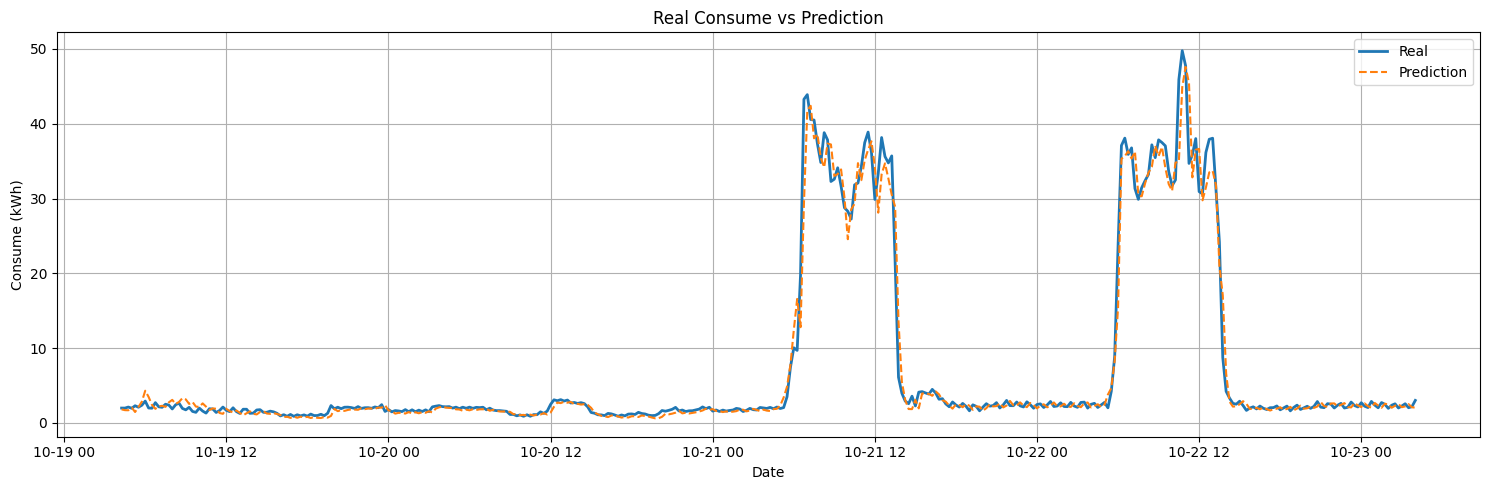

In [99]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=1730, n_dias=4, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=0, n_dias=4, idx=1780)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


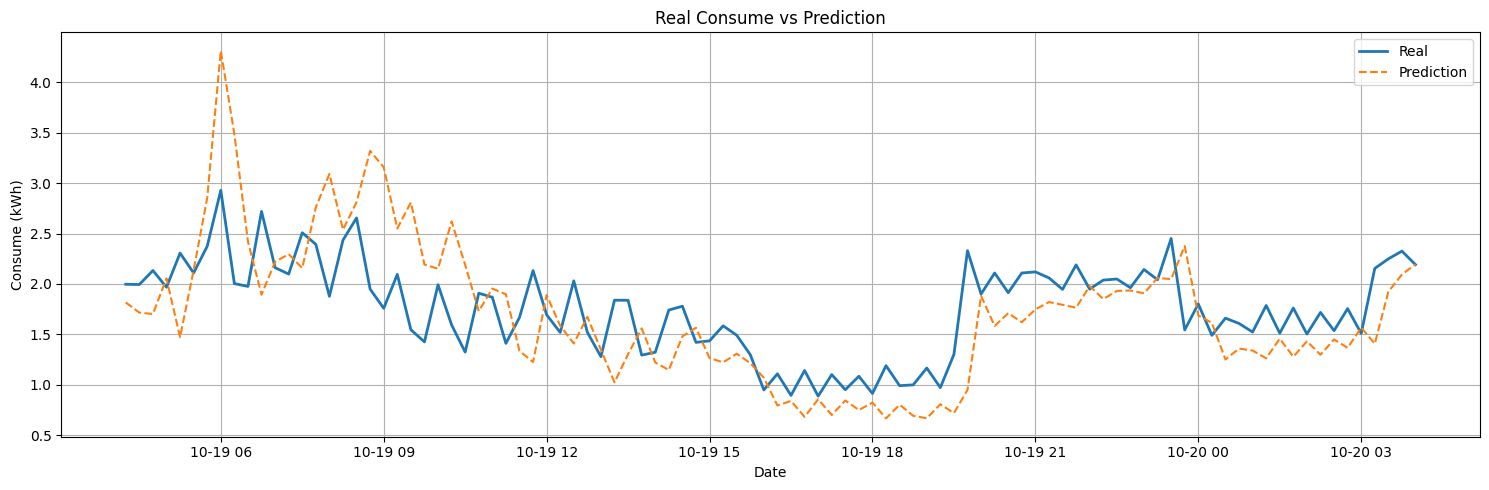

In [100]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=1730, n_dias=1, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=0, n_dias=1, idx=1780)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Anomalías fuertes detectadas: 13


C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\2684735478.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False


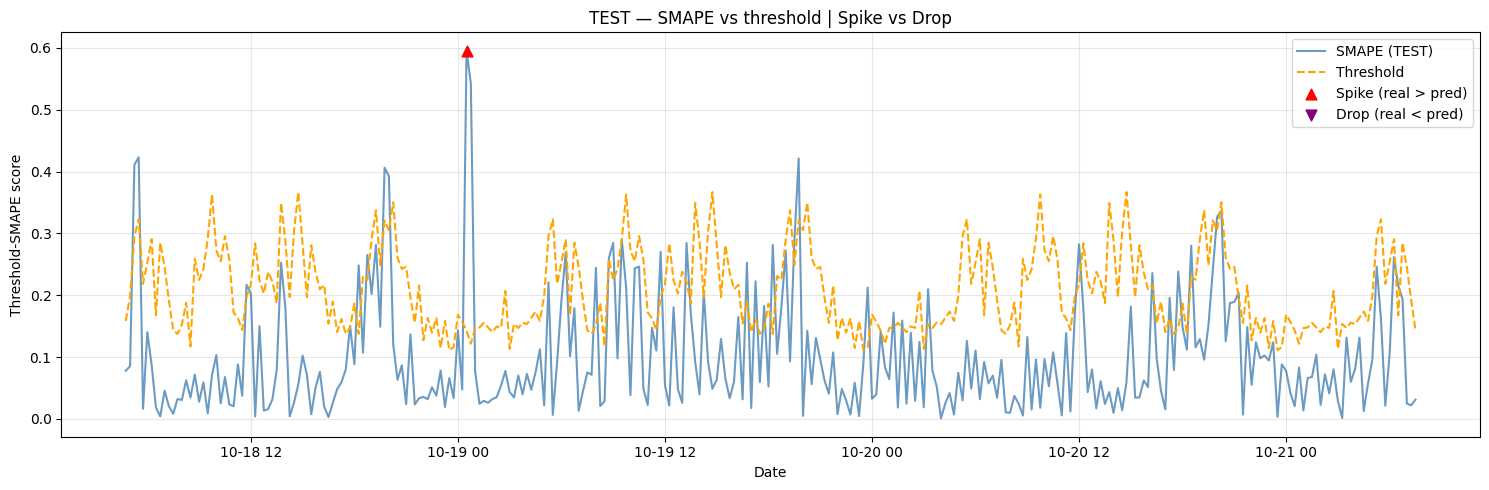

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Predicción en escala normalizada
y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred_scaled_vl = model_BiLSTM.predict([X_val_temporal, X_val_stat])

# Desescalar
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred = np.clip(y_pred, a_min=0, a_max=None)
y_real = scaler.inverse_transform(y_ts.reshape(-1, 1)).ravel()

y_pred_vl = scaler.inverse_transform(y_pred_scaled_vl.reshape(-1, 1)).ravel()
y_pred_vl = np.clip(y_pred_vl, a_min=0, a_max=None)
y_real_vl = scaler.inverse_transform(y_vl.reshape(-1, 1)).ravel()

# ── VAL ──────────────────────────────────────────────────────────────────────
df_vl = pd.DataFrame({
    'y_real': y_real_vl,
    'y_pred': y_pred_vl,
}, index=val[96:-1].index)

df_vl['quarter'] = df_vl.index.hour * 4 + df_vl.index.minute // 15
df_vl['error_kwh'] = np.abs(df_vl['y_real'] - df_vl['y_pred'])
df_vl['score_rel'] = df_vl['error_kwh'] / np.clip(df_vl['y_real'] + df_vl['y_pred'], a_min=1e-3, a_max=None)

P = 95
tau_by_context = df_vl.groupby('quarter')['score_rel'].quantile(P / 100)
df_vl['tau'] = df_vl['quarter'].map(tau_by_context)

# ── TEST ─────────────────────────────────────────────────────────────────────
df_test = pd.DataFrame({
    'y_real': y_real,
    'y_pred': y_pred,
}, index=test[96:-1].index)

df_test['quarter'] = df_test.index.hour * 4 + df_test.index.minute // 15
df_test['error_kwh'] = np.abs(df_test['y_real'] - df_test['y_pred'])
df_test['score_rel'] = df_test['error_kwh'] / np.clip(df_test['y_real'] + df_test['y_pred'], a_min=1e-3, a_max=None)

df_test['tau'] = df_test['quarter'].map(tau_by_context)

df_test['anomaly_strong'] = df_test['score_rel'] > (df_test['tau'] + 0.3)
df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False
df_test['anomaly'] = df_test['score_rel'] > (df_test['tau'] + 0.1)

if df_test['anomaly_strong'].sum() > 0:
    print(f"Anomalías fuertes detectadas: {df_test['anomaly_strong'].sum()}")

# ── Anomaly type (solo sobre anomaly_strong) ──────────────────────────────────
df_test['anomaly_type_pred'] = 'none'
mask = df_test['anomaly_strong']
df_test.loc[mask & (df_test['y_real'] > df_test['y_pred']), 'anomaly_type_pred'] = 'spike'
df_test.loc[mask & (df_test['y_real'] < df_test['y_pred']), 'anomaly_type_pred'] = 'drop'

df_test['anomaly_final'] = df_test['anomaly_strong']

import json


threshold_data = {
    "tau_by_context": tau_by_context.to_dict(),  # dict {quarter: tau}
    "horas": df_test.index.astype(str).tolist(),   
    "tau": df_test['tau'].tolist()                
}

with open("threshold_Empresa C1.json", "w") as f:
    json.dump(threshold_data, f, indent=2)

# ── Plot ──────────────────────────────────────────────────────────────────────
start = 0
end   = 300

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    df_test.index[start:end],
    df_test['score_rel'].iloc[start:end],
    label='SMAPE (TEST)', color='steelblue', alpha=0.8
)
ax.plot(
    df_test.index[start:end],
    df_test['tau'].iloc[start:end],
    '--', label='Threshold', color='orange'
)

spikes = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'spike']
ax.scatter(spikes.index, spikes['score_rel'],
           color='red', marker='^', s=60, label='Spike (real > pred)', zorder=5)

drops = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'drop']
ax.scatter(drops.index, drops['score_rel'],
           color='purple', marker='v', s=60, label='Drop (real < pred)', zorder=5)

ax.set_title('TEST — SMAPE vs threshold | Spike vs Drop')
ax.set_xlabel('Date')
ax.set_ylabel('Threshold-SMAPE score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
df_test['is_anomaly'] = df.loc[df_test.index, 'is_anomaly']
df_test['anomaly_type'] = anomaly.loc[df_test.index]
y_true1 = df_test['is_anomaly'].astype(int)
y_pred1 = df_test['anomaly_final'].astype(int)

In [103]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true1, y_pred1)
print(cm)

[[2984    5]
 [   2    8]]


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_true1, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2989
           1       0.62      0.80      0.70        10

    accuracy                           1.00      2999
   macro avg       0.81      0.90      0.85      2999
weighted avg       1.00      1.00      1.00      2999




  TIPO: spike

Número total de anomalías reales de tipo 'spike': 5
Anomalía 1/5 — índice posicional 2 — ⚠️ No detectada (FN)


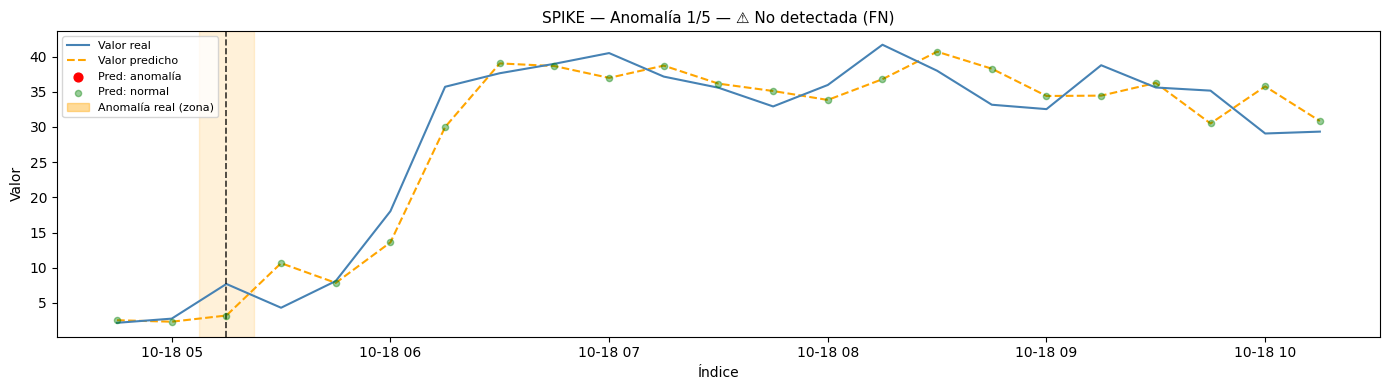

Anomalía 2/5 — índice posicional 79 — ✅ Detectada (TP)


C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\480084871.py:155: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


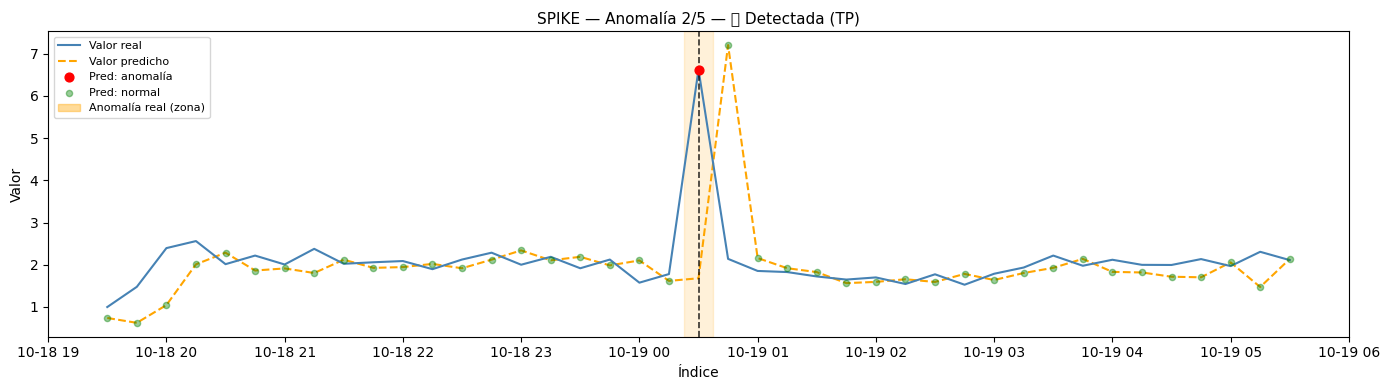

Anomalía 3/5 — índice posicional 1637 — ✅ Detectada (TP)


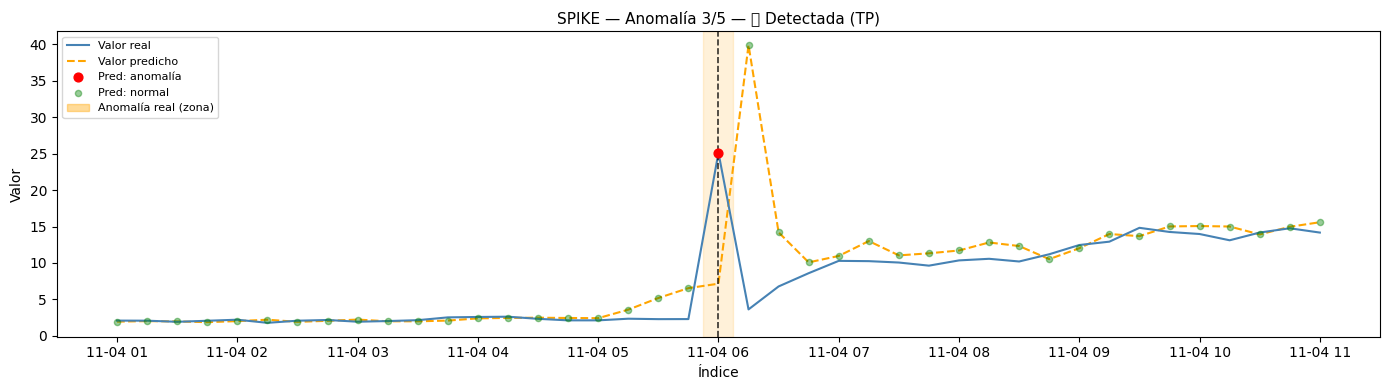

Anomalía 4/5 — índice posicional 1907 — ✅ Detectada (TP)


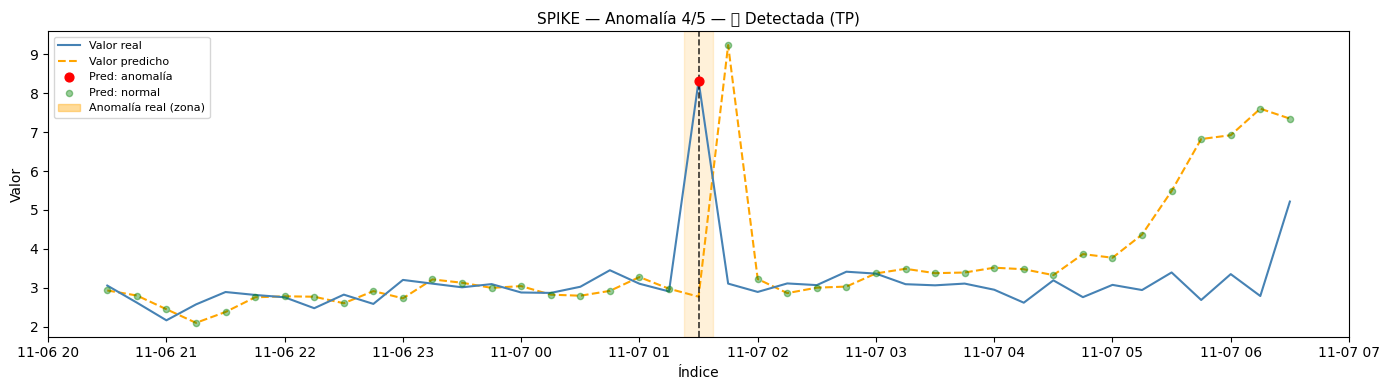

Anomalía 5/5 — índice posicional 2849 — ⚠️ No detectada (FN)


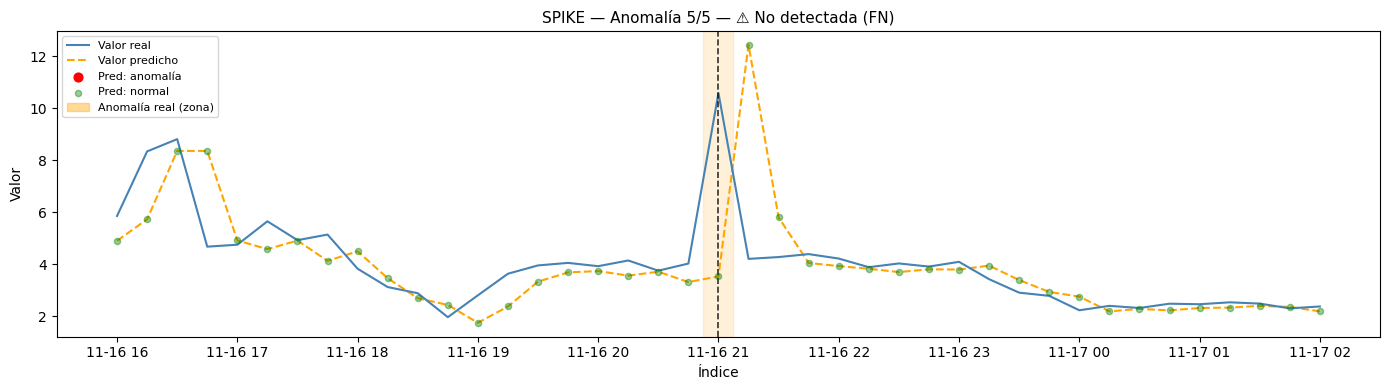


Resumen de SPIKE:
  Detectadas     : 3
  No detectadas  : 2
  Total          : 5

  TIPO: drop

Número total de anomalías reales de tipo 'drop': 5
Anomalía 1/5 — índice posicional 729 — ✅ Detectada (TP)


C:\Users\andy0\AppData\Local\Temp\ipykernel_16708\480084871.py:155: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


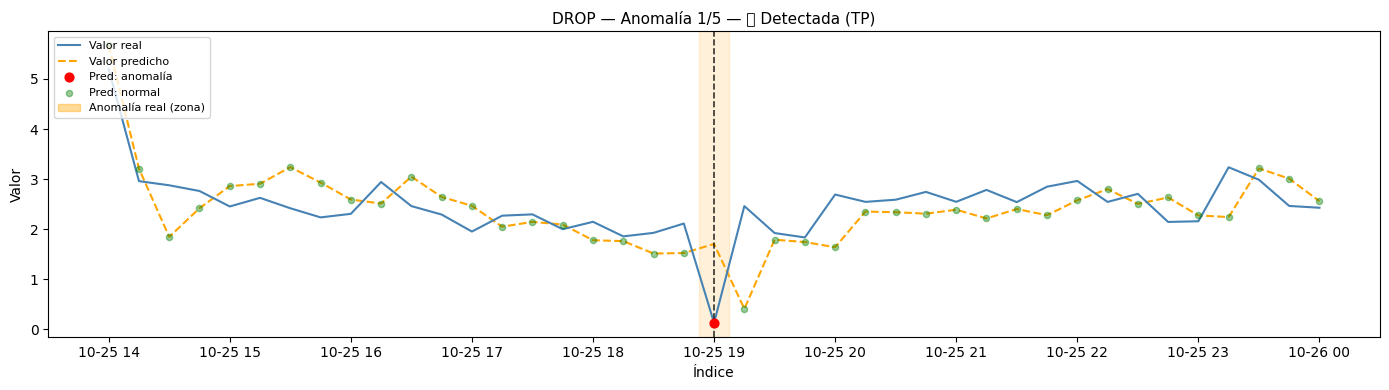

Anomalía 2/5 — índice posicional 960 — ✅ Detectada (TP)


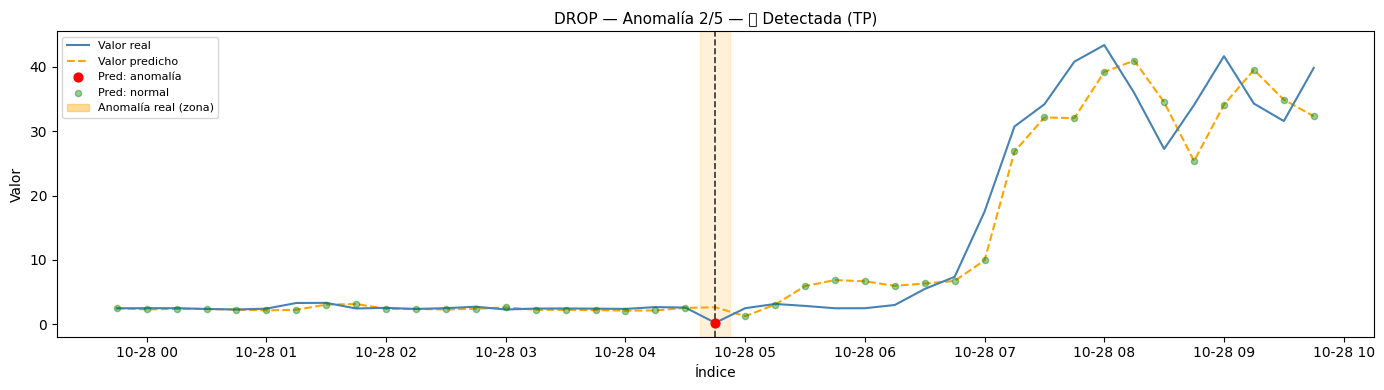

Anomalía 3/5 — índice posicional 1157 — ✅ Detectada (TP)


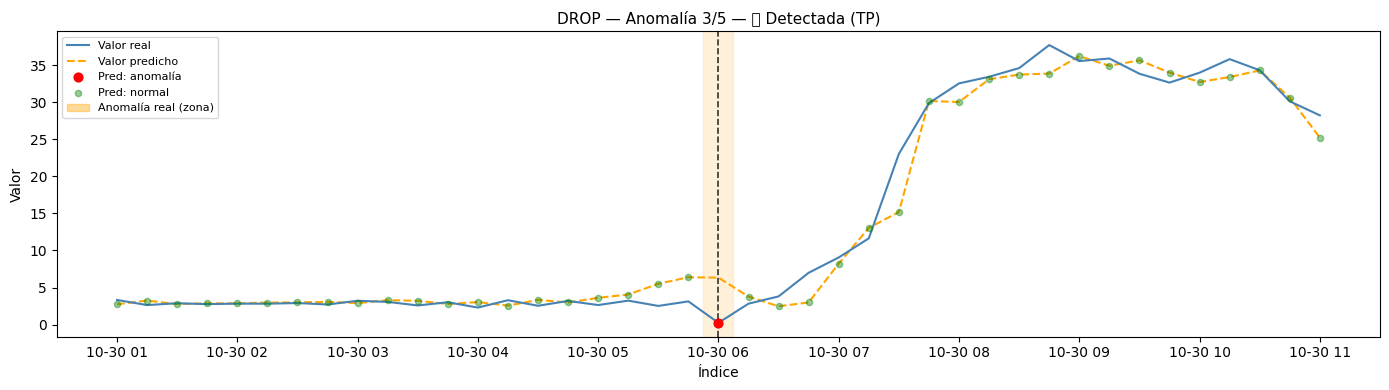

Anomalía 4/5 — índice posicional 1883 — ✅ Detectada (TP)


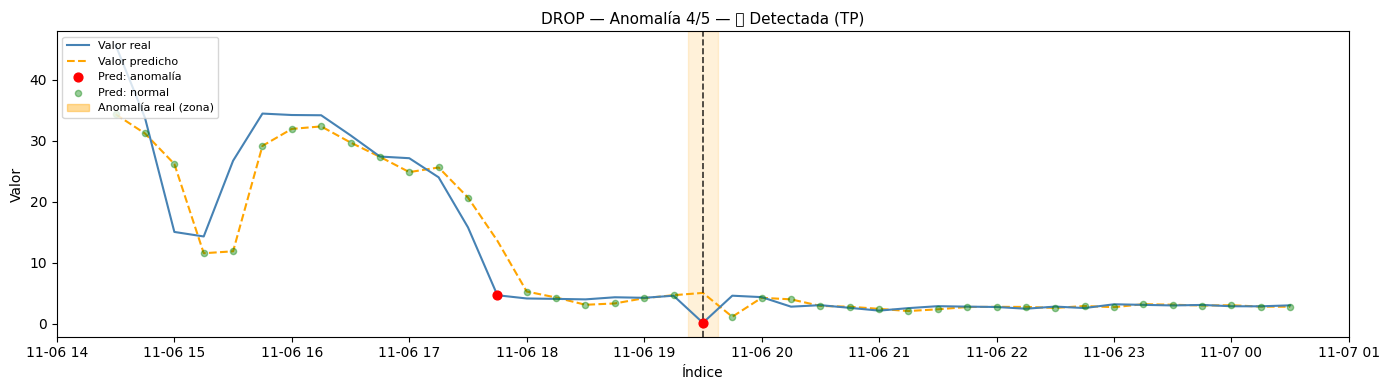

Anomalía 5/5 — índice posicional 1997 — ✅ Detectada (TP)


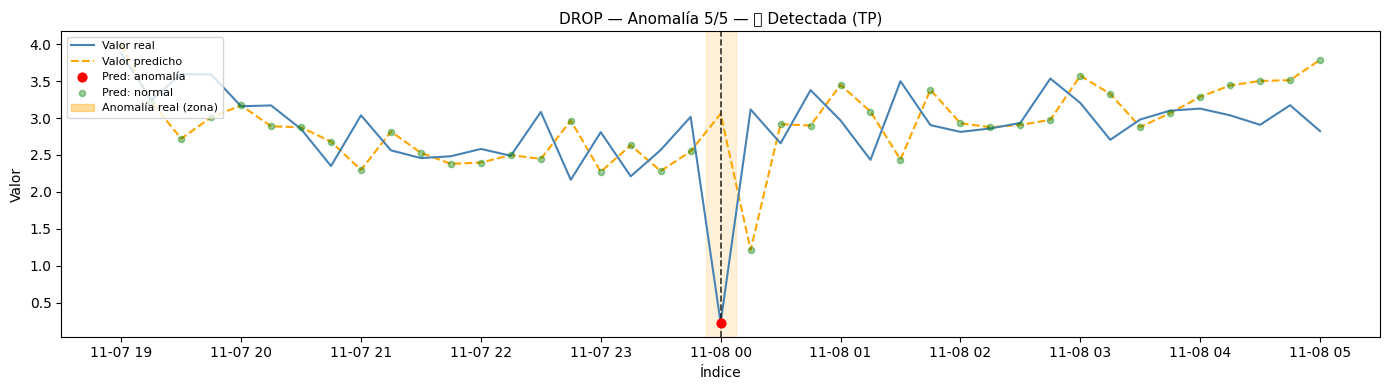


Resumen de DROP:
  Detectadas     : 5
  No detectadas  : 0
  Total          : 5


In [106]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


# Tipos de anomalías que queremos representar
case_types = ['spike', 'drop']


def plot_caso(df, idx, titulo="", ventana=20):
    """
    Dibuja una ventana alrededor de una anomalía concreta.

    Parámetros
    ----------
    df : DataFrame
        DataFrame que contiene los datos reales, predichos
        y las etiquetas de anomalías.

    idx : int
        Posición de la anomalía dentro del DataFrame.

    titulo : str
        Título que se mostrará en la gráfica.

    ventana : int
        Número de puntos anteriores y posteriores que se muestran.
    """

    # Límites de la ventana que se va a representar
    start = max(0, idx - ventana)
    end = min(len(df), idx + ventana + 1)

    subset = df.iloc[start:end]

    # Crear figura
    fig, ax = plt.subplots(figsize=(14, 4))

    # ---------------------------------------------------------
    # Valores reales y predichos
    # ---------------------------------------------------------
    ax.plot(
        subset.index,
        subset['y_real'],
        color='steelblue',
        linewidth=1.5,
        label='Valor real',
        zorder=3
    )

    ax.plot(
        subset.index,
        subset['y_pred'],
        color='orange',
        linestyle='--',
        label='Valor predicho',
        zorder=2
    )

    # ---------------------------------------------------------
    # Predicciones del detector
    # ---------------------------------------------------------
    pred_pos = subset[subset['anomaly_strong'] == 1]
    pred_neg = subset[subset['anomaly_strong'] == 0]

    # Puntos considerados anomalía
    ax.scatter(
        pred_pos.index,
        pred_pos['y_real'],
        color='red',
        s=40,
        zorder=5,
        label='Pred: anomalía'
    )

    # Puntos considerados normales
    ax.scatter(
        pred_neg.index,
        pred_neg['y_pred'],
        color='green',
        s=20,
        zorder=5,
        label='Pred: normal',
        alpha=0.4
    )

    # ---------------------------------------------------------
    # Calcular el tamaño temporal de cada intervalo
    # para sombrear las anomalías reales
    # ---------------------------------------------------------
    if hasattr(subset.index, 'freq') and subset.index.freq is not None:

        half_step = pd.tseries.frequencies.to_offset(
            subset.index.freq
        ) / 2

    else:
        diffs = pd.Series(subset.index).diff().dropna()
        half_step = diffs.median() / 2

    # ---------------------------------------------------------
    # Sombrear TODAS las anomalías reales presentes
    # dentro de la ventana
    # ---------------------------------------------------------
    for i in subset.index:

        if subset.loc[i, 'anomaly_type'] != 'none':

            ax.axvspan(
                i - half_step,
                i + half_step,
                alpha=0.15,
                color='orange',
                zorder=1
            )

    # ---------------------------------------------------------
    # Línea vertical que marca la anomalía que estamos analizando
    # ---------------------------------------------------------
    punto_x = df.index[idx]

    ax.axvline(
        x=punto_x,
        color='black',
        linestyle='--',
        linewidth=1.2,
        alpha=0.8,
        zorder=4
    )

    # ---------------------------------------------------------
    # Configuración de la gráfica
    # ---------------------------------------------------------
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Índice")
    ax.set_ylabel("Valor")

    # Leyenda para la zona sombreada
    naranja = mpatches.Patch(
        color='orange',
        alpha=0.4,
        label='Anomalía real (zona)'
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles=handles + [naranja],
        labels=labels + ['Anomalía real (zona)'],
        fontsize=8,
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()


# =============================================================
# REPRESENTAR TODAS LAS ANOMALÍAS REALES
# =============================================================

for t in case_types:

    print(f"\n{'=' * 55}")
    print(f"  TIPO: {t}")
    print(f"{'=' * 55}")

    # ---------------------------------------------------------
    # Etiqueta real
    # ---------------------------------------------------------
    # Vale 1 cuando realmente existe una anomalía de este tipo
    y_true = (df_test['anomaly_type'] == t).astype(int)

    # ---------------------------------------------------------
    # Etiqueta predicha
    # ---------------------------------------------------------
    # Vale 1 cuando el modelo ha predicho esta anomalía
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)

    # ---------------------------------------------------------
    # Obtener TODAS las anomalías reales de este tipo
    # ---------------------------------------------------------
    indices_anomalias = np.where(y_true == 1)[0]

    if len(indices_anomalias) == 0:
        print(f"\nNo hay anomalías reales de tipo '{t}'.")
        continue

    print(
        f"\nNúmero total de anomalías reales de tipo "
        f"'{t}': {len(indices_anomalias)}"
    )

    # Contadores
    detectadas = 0
    no_detectadas = 0

    # ---------------------------------------------------------
    # Dibujar una gráfica para CADA anomalía real
    # ---------------------------------------------------------
    for numero, idx_pos in enumerate(indices_anomalias, start=1):

        # Comprobar si esa anomalía fue detectada
        if y_pred.iloc[idx_pos] == 1:

            resultado = "✅ Detectada (TP)"
            detectadas += 1

        else:

            resultado = "⚠️ No detectada (FN)"
            no_detectadas += 1

        # Mostrar información por pantalla
        print(
            f"Anomalía {numero}/{len(indices_anomalias)} "
            f"— índice posicional {idx_pos} "
            f"— {resultado}"
        )

        # Dibujar la gráfica
        plot_caso(
            df_test,
            idx=idx_pos,
            titulo=(
                f"{t.upper()} — "
                f"Anomalía {numero}/{len(indices_anomalias)} — "
                f"{resultado}"
            ),
            ventana=20
        )

    # ---------------------------------------------------------
    # Resumen del tipo de anomalía
    # ---------------------------------------------------------
    print(f"\nResumen de {t.upper()}:")
    print(f"  Detectadas     : {detectadas}")
    print(f"  No detectadas  : {no_detectadas}")
    print(f"  Total          : {len(indices_anomalias)}")

In [ ]:
model_BiLSTM.save("model_BiLSTM_Empresa C1.keras")